# Tensor Core vs CUDA Core Benchmark (A100)

This notebook runs the PyTorch benchmark, compiles and runs the cuBLAS C++ benchmark, and generates comparison plots.

In [7]:
!nvidia-smi
%pip install -q pandas matplotlib

Tue Mar 24 09:39:19 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   29C    P0             41W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [8]:
import os
from pathlib import Path

workdir = Path('/content/tensorcore_vs_cudacore_notebook')
workdir.mkdir(parents=True, exist_ok=True)
os.chdir(workdir)

print('Working directory set to:', Path.cwd())

Working directory set to: /content/tensorcore_vs_cudacore_notebook


In [9]:
import pandas as pd
import torch
import torch.nn as nn

device = 'cuda' if torch.cuda.is_available() else 'cpu'

def set_tf32(enabled: bool) -> None:
    if torch.cuda.is_available():
        torch.backends.cuda.matmul.allow_tf32 = enabled
        torch.backends.cudnn.allow_tf32 = enabled

def tflops(B: int, K: int, N: int, latency_ms: float) -> float:
    flops = 2.0 * B * K * N
    seconds = latency_ms / 1000.0
    return flops / seconds / 1e12

def benchmark_once(
    B: int,
    K: int,
    N: int,
    use_tf32: bool,
    warmup: int = 20,
    iters: int = 100,
) -> float:
    if device != 'cuda':
        raise RuntimeError('This benchmark must run on a CUDA GPU.')

    set_tf32(use_tf32)

    x = torch.randn(B, K, device=device, dtype=torch.float32)
    fc = nn.Linear(K, N, bias=False, device=device, dtype=torch.float32)
    fc.eval()

    for _ in range(warmup):
        _ = fc(x)
    torch.cuda.synchronize()

    start = torch.cuda.Event(enable_timing=True)
    end = torch.cuda.Event(enable_timing=True)

    start.record()
    for _ in range(iters):
        _ = fc(x)
    end.record()

    torch.cuda.synchronize()
    avg_ms = start.elapsed_time(end) / iters
    return avg_ms

sizes = [
    (128, 512, 512),
    (128, 1024, 1024),
    (256, 1024, 1024),
    (256, 2048, 2048),
    (512, 2048, 2048),
    (1024, 4096, 4096),
]

rows = []

for B, K, N in sizes:
    baseline_ms = benchmark_once(B, K, N, use_tf32=False)
    tf32_ms = benchmark_once(B, K, N, use_tf32=True)

    baseline_tflops = tflops(B, K, N, baseline_ms)
    tf32_tflops = tflops(B, K, N, tf32_ms)
    speedup = baseline_ms / tf32_ms

    rows.append(
        {
            'B': B,
            'K': K,
            'N': N,
            'baseline_ms': baseline_ms,
            'tf32_ms': tf32_ms,
            'baseline_tflops': baseline_tflops,
            'tf32_tflops': tf32_tflops,
            'speedup': speedup,
        }
    )

df = pd.DataFrame(rows)
print(df)
df.to_csv('results_pytorch.csv', index=False)
print('Saved results to results_pytorch.csv')

      B     K     N  baseline_ms   tf32_ms  baseline_tflops  tf32_tflops  \
0   128   512   512     0.033833  0.038758         1.983535     1.731466   
1   128  1024  1024     0.046387  0.034519         5.786843     7.776446   
2   256  1024  1024     0.058921  0.034202         9.111714    15.697245   
3   256  2048  2048     0.166257  0.052654        12.916679    40.784753   
4   512  2048  2048     0.300544  0.070953        14.290644    60.532603   
5  1024  4096  4096     1.976924  0.287918        17.380403   119.338596   

    speedup  
0  0.872919  
1  1.343815  
2  1.722754  
3  3.157526  
4  4.235820  
5  6.866273  
Saved results to results_pytorch.csv


In [10]:
%%writefile cuda_bench.cu
#include <cublas_v2.h>
#include <cuda_runtime.h>

#include <fstream>
#include <iomanip>
#include <iostream>
#include <random>
#include <tuple>
#include <vector>

#define CHECK_CUDA(expr)                                                        \
  do {                                                                          \
    cudaError_t _err = (expr);                                                  \
    if (_err != cudaSuccess) {                                                  \
      std::cerr << "CUDA error: " << cudaGetErrorString(_err)                  \
                << " at " << __FILE__ << ":" << __LINE__ << std::endl;        \
      std::exit(EXIT_FAILURE);                                                  \
    }                                                                           \
  } while (0)

#define CHECK_CUBLAS(expr)                                                      \
  do {                                                                          \
    cublasStatus_t _stat = (expr);                                              \
    if (_stat != CUBLAS_STATUS_SUCCESS) {                                       \
      std::cerr << "cuBLAS error code " << static_cast<int>(_stat)             \
                << " at " << __FILE__ << ":" << __LINE__ << std::endl;        \
      std::exit(EXIT_FAILURE);                                                  \
    }                                                                           \
  } while (0)

enum class GemmMode {
  BaselineSgemm,
  TensorCoreTf32,
};

float tflops(int B, int K, int N, float latency_ms) {
  const double flops = 2.0 * static_cast<double>(B) * static_cast<double>(K) *
                       static_cast<double>(N);
  const double seconds = static_cast<double>(latency_ms) / 1000.0;
  return static_cast<float>(flops / seconds / 1e12);
}

float benchmark_once(cublasHandle_t handle, const float* d_x, const float* d_w,
                     float* d_c, int B, int K, int N, GemmMode mode,
                     int warmup = 20, int iters = 100) {
  const float alpha = 1.0f;
  const float beta = 0.0f;

  if (mode == GemmMode::BaselineSgemm) {
    CHECK_CUBLAS(cublasSetMathMode(handle, CUBLAS_PEDANTIC_MATH));
  } else {
    CHECK_CUBLAS(cublasSetMathMode(handle, CUBLAS_TF32_TENSOR_OP_MATH));
  }

  for (int i = 0; i < warmup; ++i) {
    if (mode == GemmMode::BaselineSgemm) {
      CHECK_CUBLAS(cublasSgemm(handle, CUBLAS_OP_N, CUBLAS_OP_N,
                               /*m=*/N, /*n=*/B, /*k=*/K, &alpha,
                               /*A=*/d_w, /*lda=*/N,
                               /*B=*/d_x, /*ldb=*/K, &beta,
                               /*C=*/d_c, /*ldc=*/N));
    } else {
      CHECK_CUBLAS(cublasGemmEx(
          handle, CUBLAS_OP_N, CUBLAS_OP_N,
          /*m=*/N, /*n=*/B, /*k=*/K, &alpha,
          /*A=*/d_w, CUDA_R_32F, /*lda=*/N,
          /*B=*/d_x, CUDA_R_32F, /*ldb=*/K, &beta,
          /*C=*/d_c, CUDA_R_32F, /*ldc=*/N,
          CUBLAS_COMPUTE_32F_FAST_TF32, CUBLAS_GEMM_DEFAULT));
    }
  }
  CHECK_CUDA(cudaDeviceSynchronize());

  cudaEvent_t start, stop;
  CHECK_CUDA(cudaEventCreate(&start));
  CHECK_CUDA(cudaEventCreate(&stop));

  CHECK_CUDA(cudaEventRecord(start));
  for (int i = 0; i < iters; ++i) {
    if (mode == GemmMode::BaselineSgemm) {
      CHECK_CUBLAS(cublasSgemm(handle, CUBLAS_OP_N, CUBLAS_OP_N,
                               /*m=*/N, /*n=*/B, /*k=*/K, &alpha,
                               /*A=*/d_w, /*lda=*/N,
                               /*B=*/d_x, /*ldb=*/K, &beta,
                               /*C=*/d_c, /*ldc=*/N));
    } else {
      CHECK_CUBLAS(cublasGemmEx(
          handle, CUBLAS_OP_N, CUBLAS_OP_N,
          /*m=*/N, /*n=*/B, /*k=*/K, &alpha,
          /*A=*/d_w, CUDA_R_32F, /*lda=*/N,
          /*B=*/d_x, CUDA_R_32F, /*ldb=*/K, &beta,
          /*C=*/d_c, CUDA_R_32F, /*ldc=*/N,
          CUBLAS_COMPUTE_32F_FAST_TF32, CUBLAS_GEMM_DEFAULT));
    }
  }
  CHECK_CUDA(cudaEventRecord(stop));
  CHECK_CUDA(cudaEventSynchronize(stop));

  float total_ms = 0.0f;
  CHECK_CUDA(cudaEventElapsedTime(&total_ms, start, stop));

  CHECK_CUDA(cudaEventDestroy(start));
  CHECK_CUDA(cudaEventDestroy(stop));

  return total_ms / static_cast<float>(iters);
}

int main() {
  int device_count = 0;
  CHECK_CUDA(cudaGetDeviceCount(&device_count));
  if (device_count == 0) {
    std::cerr << "No CUDA device found." << std::endl;
    return EXIT_FAILURE;
  }

  cublasHandle_t handle;
  CHECK_CUBLAS(cublasCreate(&handle));

  std::vector<std::tuple<int, int, int>> sizes = {
      {128, 512, 512},
      {128, 1024, 1024},
      {256, 1024, 1024},
      {256, 2048, 2048},
      {512, 2048, 2048},
      {1024, 4096, 4096},
  };

  std::ofstream csv("results_cublas.csv");
  csv << "B,K,N,baseline_ms,tf32_ms,baseline_tflops,tf32_tflops,speedup\n";
  csv << std::fixed << std::setprecision(6);

  std::mt19937 rng(42);
  std::uniform_real_distribution<float> dist(-1.0f, 1.0f);

  for (const auto& [B, K, N] : sizes) {
    const size_t x_elems = static_cast<size_t>(B) * K;
    const size_t w_elems = static_cast<size_t>(K) * N;
    const size_t c_elems = static_cast<size_t>(B) * N;

    std::vector<float> h_x(x_elems);
    std::vector<float> h_w(w_elems);

    for (size_t i = 0; i < x_elems; ++i) {
      h_x[i] = dist(rng);
    }
    for (size_t i = 0; i < w_elems; ++i) {
      h_w[i] = dist(rng);
    }

    float *d_x = nullptr, *d_w = nullptr, *d_c = nullptr;
    CHECK_CUDA(cudaMalloc(&d_x, x_elems * sizeof(float)));
    CHECK_CUDA(cudaMalloc(&d_w, w_elems * sizeof(float)));
    CHECK_CUDA(cudaMalloc(&d_c, c_elems * sizeof(float)));

    CHECK_CUDA(cudaMemcpy(d_x, h_x.data(), x_elems * sizeof(float),
                          cudaMemcpyHostToDevice));
    CHECK_CUDA(cudaMemcpy(d_w, h_w.data(), w_elems * sizeof(float),
                          cudaMemcpyHostToDevice));

    const float baseline_ms = benchmark_once(
        handle, d_x, d_w, d_c, B, K, N, GemmMode::BaselineSgemm);
    const float tf32_ms = benchmark_once(
        handle, d_x, d_w, d_c, B, K, N, GemmMode::TensorCoreTf32);

    const float baseline_tf = tflops(B, K, N, baseline_ms);
    const float tf32_tf = tflops(B, K, N, tf32_ms);
    const float speedup = baseline_ms / tf32_ms;

    std::cout << "B=" << B << " K=" << K << " N=" << N
              << " | baseline_ms=" << baseline_ms
              << " tf32_ms=" << tf32_ms << " speedup=" << speedup
              << std::endl;

    csv << B << "," << K << "," << N << "," << baseline_ms << ","
        << tf32_ms << "," << baseline_tf << "," << tf32_tf << ","
        << speedup << "\n";

    CHECK_CUDA(cudaFree(d_x));
    CHECK_CUDA(cudaFree(d_w));
    CHECK_CUDA(cudaFree(d_c));
  }

  CHECK_CUBLAS(cublasDestroy(handle));
  csv.close();

  std::cout << "Saved results to results_cublas.csv" << std::endl;
  return 0;
}

!nvcc -O3 -std=c++17 cuda_bench.cu -o cuda_bench -lcublas
!./cuda_bench

Writing cuda_bench.cu


Saved latency_comparison.png, throughput_comparison.png, and speedup_comparison.png


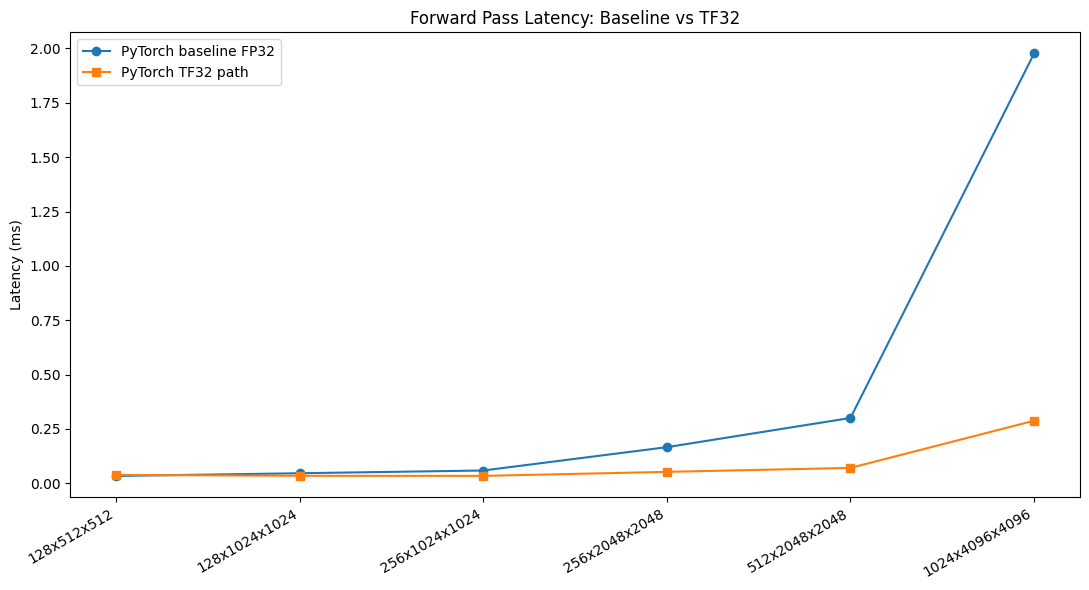

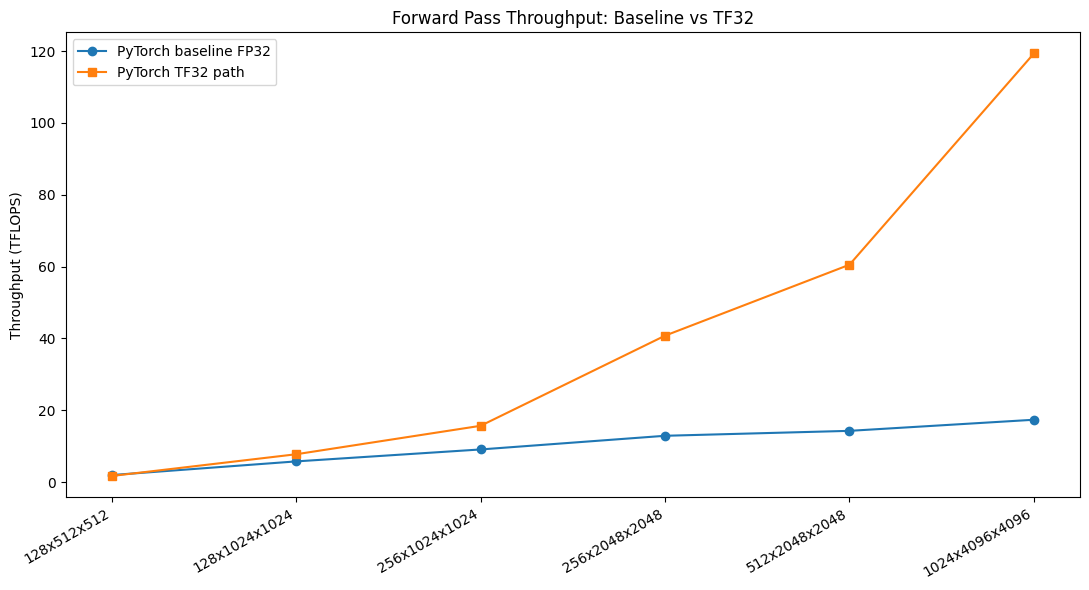

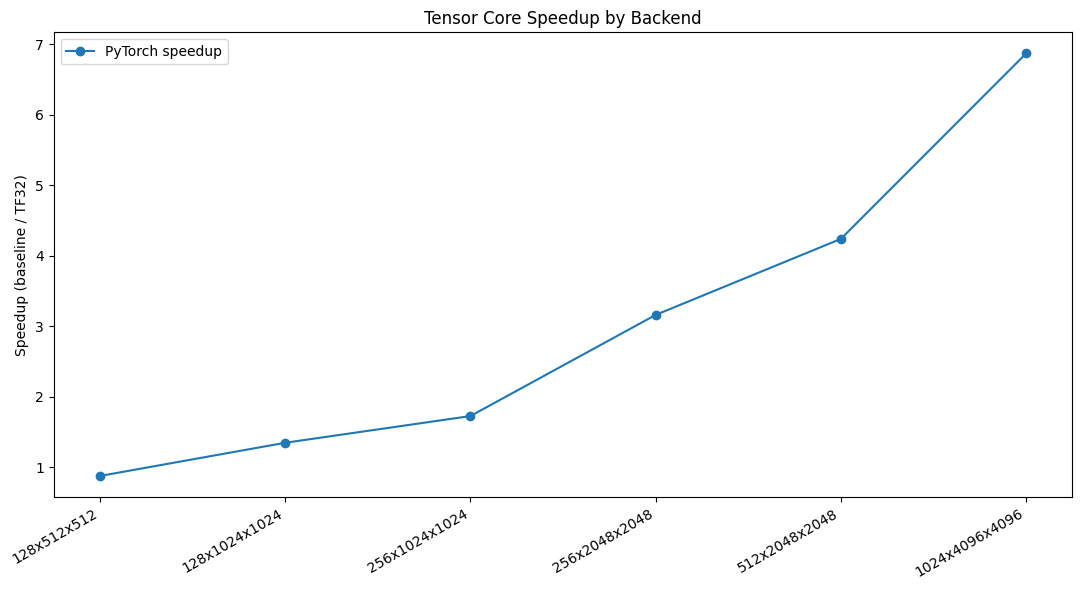

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

pytorch_csv = Path('results_pytorch.csv')
cublas_csv = Path('results_cublas.csv')

if not pytorch_csv.exists() and not cublas_csv.exists():
    raise FileNotFoundError(
        'No input CSV found. Run the previous benchmark cells first.'
    )

frames = {}
if pytorch_csv.exists():
    frames['PyTorch'] = pd.read_csv(pytorch_csv)
if cublas_csv.exists():
    frames['cuBLAS'] = pd.read_csv(cublas_csv)

first_df = next(iter(frames.values()))
x = list(range(len(first_df)))
labels = [
    f"{b}x{k}x{n}"
    for b, k, n in zip(first_df['B'], first_df['K'], first_df['N'])
]

# Save figures to disk and close them to avoid duplicate notebook rendering.
fig = plt.figure(figsize=(11, 6))
for name, df in frames.items():
    plt.plot(x, df['baseline_ms'], marker='o', label=f'{name} baseline FP32')
    plt.plot(x, df['tf32_ms'], marker='s', label=f'{name} TF32 path')
plt.xticks(x, labels, rotation=30, ha='right')
plt.ylabel('Latency (ms)')
plt.title('Forward Pass Latency: Baseline vs TF32')
plt.legend()
plt.tight_layout()
plt.savefig('latency_comparison.png')
plt.close(fig)

fig = plt.figure(figsize=(11, 6))
for name, df in frames.items():
    plt.plot(
        x,
        df['baseline_tflops'],
        marker='o',
        label=f'{name} baseline FP32',
    )
    plt.plot(x, df['tf32_tflops'], marker='s', label=f'{name} TF32 path')
plt.xticks(x, labels, rotation=30, ha='right')
plt.ylabel('Throughput (TFLOPS)')
plt.title('Forward Pass Throughput: Baseline vs TF32')
plt.legend()
plt.tight_layout()
plt.savefig('throughput_comparison.png')
plt.close(fig)

fig = plt.figure(figsize=(11, 6))
for name, df in frames.items():
    plt.plot(x, df['speedup'], marker='o', label=f'{name} speedup')
plt.xticks(x, labels, rotation=30, ha='right')
plt.ylabel('Speedup (baseline / TF32)')
plt.title('Tensor Core Speedup by Backend')
plt.legend()
plt.tight_layout()
plt.savefig('speedup_comparison.png')
plt.close(fig)

print(
    'Saved latency_comparison.png, throughput_comparison.png, and speedup_comparison.png'
 )

PNG files found: ['latency_comparison.png', 'throughput_comparison.png', 'speedup_comparison.png']


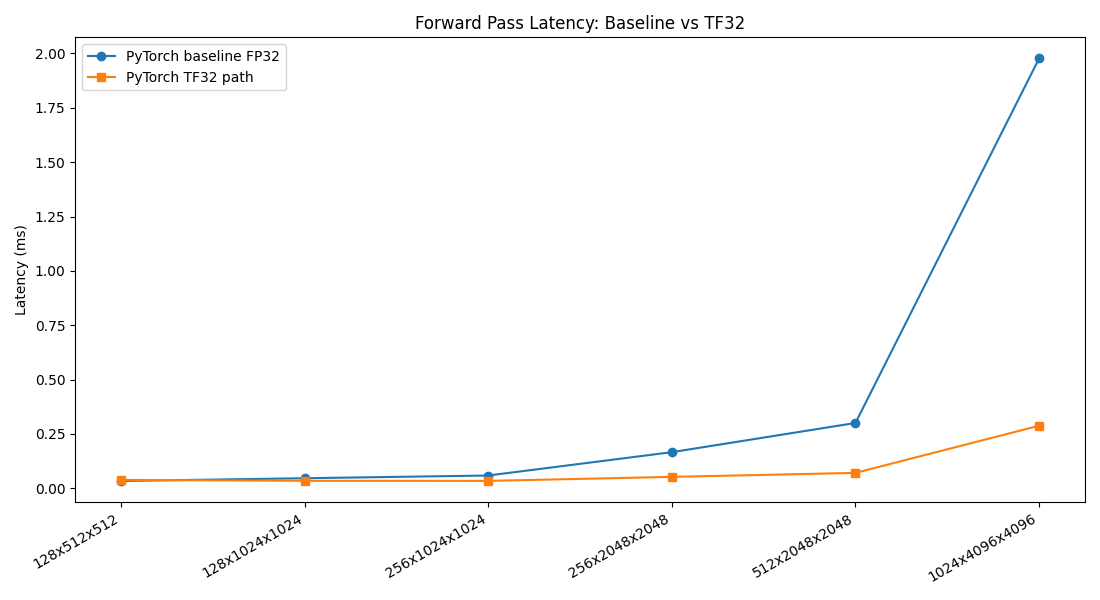

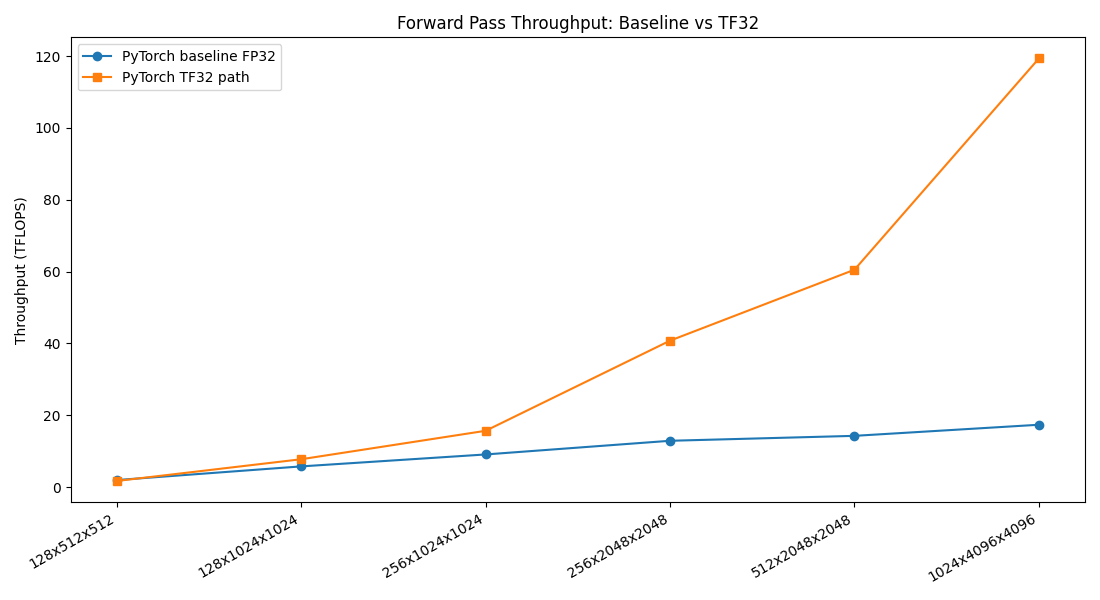

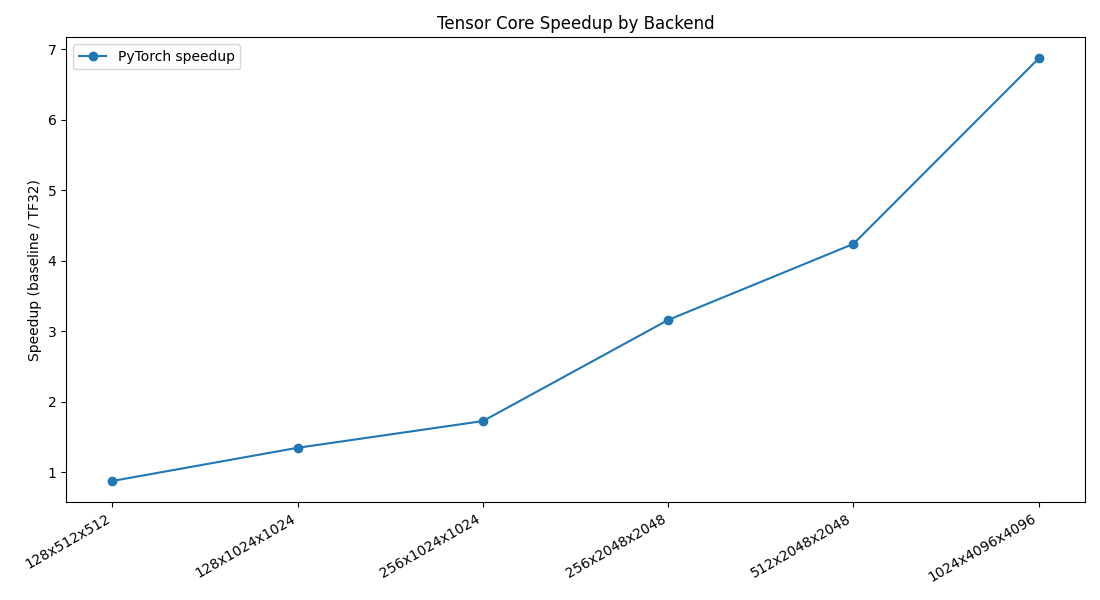

In [12]:
from pathlib import Path
from IPython.display import Image, display

# Accept either the new comparison filenames or legacy names.
candidates = [
    "latency_comparison.png",
    "throughput_comparison.png",
    "speedup_comparison.png",
    "latency.png",
    "throughput.png",
    "speedup.png",
]

existing = [p for p in candidates if Path(p).exists()]
print("PNG files found:", existing)

if not existing:
    raise FileNotFoundError(
        "No PNG plots found. Re-run the previous plotting cell and check its output."
    )

for png in existing:
    display(Image(png))